# 06. Bermudan Swaption Pricing: Python vs ORE

This notebook focuses on the native Bermudan swaption path that was added on top of the Python LGM stack.
The objective is narrower than the XVA notebooks: price a few Bermudans, compare the Python methods against
ORE classic, and inspect one case in more detail.

**Purpose**
- show the current Python Bermudan pricing methods side by side with ORE classic
- make the calibration-vs-simulation model-source point explicit
- inspect one benchmark case through its exercise diagnostics

**What you will learn**
- how close Python `backward` is to ORE classic on the current benchmark pack
- why Python `lsmc` is still useful as a control but is not the parity target
- what the Bermudan exercise diagnostics look like on the base case


In [1]:
from pathlib import Path
import os
import sys

def _find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "Tools" / "PythonOreRunner" / "notebook_series" / "series_helpers.py").exists():
            return candidate
    repo_hint = Path("/Users/gordonlee/Documents/Engine")
    if (repo_hint / "Tools" / "PythonOreRunner" / "notebook_series" / "series_helpers.py").exists():
        return repo_hint
    raise RuntimeError("Could not locate the Engine repo root from the current notebook working directory")

REPO_ROOT = _find_repo_root(Path.cwd())
NOTEBOOK_DIR = REPO_ROOT / "Tools" / "PythonOreRunner" / "notebook_series"
for path in (NOTEBOOK_DIR, REPO_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

os.environ.setdefault("MPLCONFIGDIR", "/tmp/codex-mplconfig")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import series_helpers as nh

try:
    from IPython.display import display
except Exception:
    def display(obj):
        if hasattr(obj, "to_string"):
            print(obj.to_string())
        else:
            print(obj)

repo = nh.bootstrap_notebook_env(REPO_ROOT)
nh.apply_plot_style()
print(repo)
RUN_ORE_SWIG = os.getenv("RUN_ORE_SWIG_DEMOS") == "1"


/Users/gordonlee/Documents/Engine


## Inputs reused from the repo

This notebook uses the native Bermudan benchmark pack and the Python Bermudan pricer already exercised by the regression tests:
- `Tools/PythonOreRunner/parity_artifacts/bermudan_method_compare`
- `native_xva_interface/bermudan.py`
- `native_xva_interface/tests/test_bermudan_pricer.py`


,case_name,trade_id,fixed_rate,py_lsmc,py_backward,py_lsmc_calibrated,py_backward_calibrated,ore_classic,ore_amc,ore_amc_source,py_lsmc_minus_ore_classic,py_backward_minus_ore_classic,py_lsmc_calibrated_minus_ore_classic,py_backward_calibrated_minus_ore_classic,ore_amc_minus_ore_classic,py_backward_abs_rel_diff
0,berm_100bp,BermSwp,0.01,107948.705590,96382.624000,NaN,NaN,96185.093011,NaN,unavailable(returncode=-11),11763.612579,197.530989,NaN,NaN,NaN,0.002054
1,berm_200bp,BermSwp,0.02,60925.087817,52294.674108,NaN,NaN,52289.126872,52289.126872,expected_output_fallback,8635.960945,5.547236,NaN,NaN,0.0,0.000106
2,berm_300bp,BermSwp,0.03,29987.429773,24337.233631,NaN,NaN,24384.657538,NaN,unavailable(returncode=-11),5602.772235,-47.423907,NaN,NaN,NaN,0.001945


,case_name,fixed_rate,py_lsmc,py_backward,ore_classic,ore_amc,ore_amc_source
0,berm_100bp,0.01,107948.705590,96382.624000,96185.093011,NaN,unavailable(returncode=-11)
1,berm_200bp,0.02,60925.087817,52294.674108,52289.126872,52289.126872,expected_output_fallback
2,berm_300bp,0.03,29987.429773,24337.233631,24384.657538,NaN,unavailable(returncode=-11)


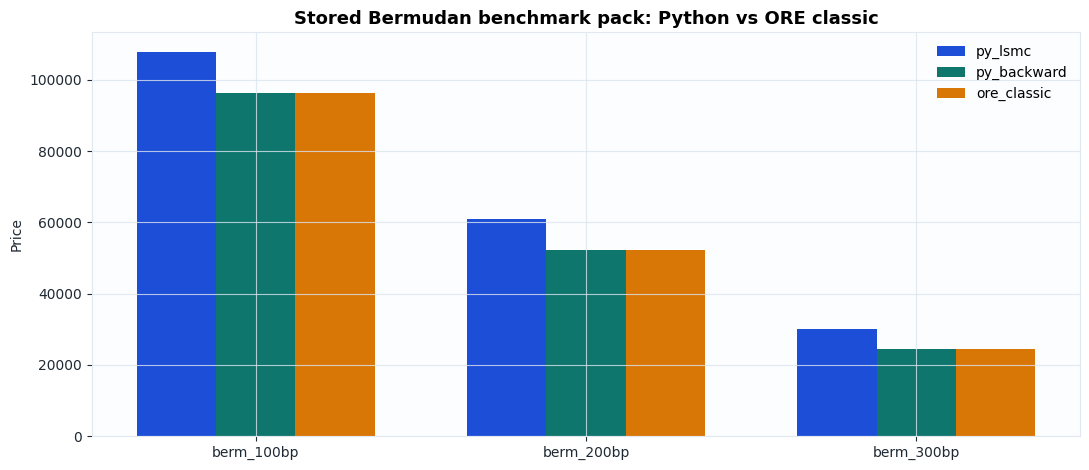

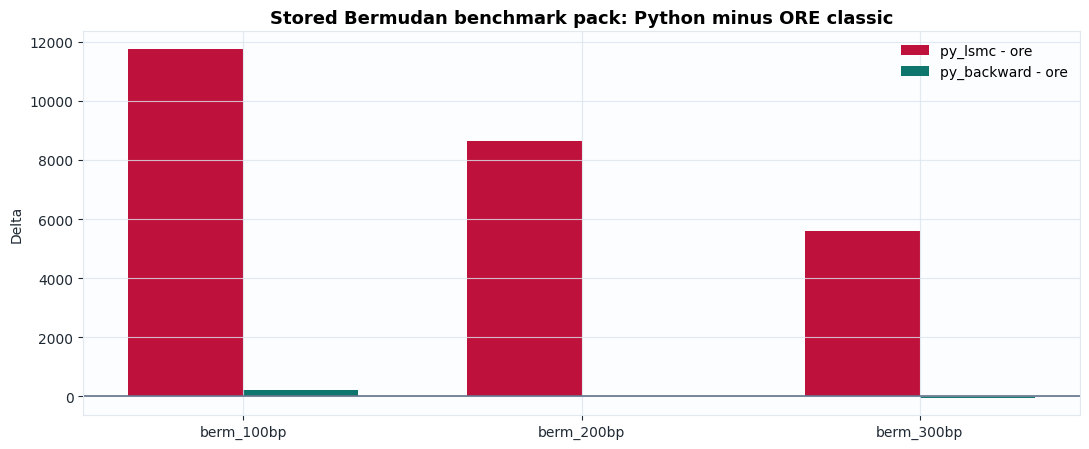

In [2]:
berm_comp = nh.load_bermudan_method_comparison()
display(berm_comp)

berm_overview = berm_comp[["case_name", "fixed_rate", "py_lsmc", "py_backward", "ore_classic", "ore_amc", "ore_amc_source"]].copy()
display(berm_overview)
nh.plot_bermudan_method_levels(berm_comp, title="Stored Bermudan benchmark pack: Python vs ORE classic")
nh.plot_bermudan_ore_deltas(berm_comp, title="Stored Bermudan benchmark pack: Python minus ORE classic")


The main thing to read off the two plots is that `py_backward` is now the ORE-classic parity method on this
benchmark pack. `py_lsmc` is still informative because it stays close to `backward`, but it is a control, not
the target engine.


## Detailed base case: 2% Bermudan

The `berm_200bp` case is the cleanest single example because it sits near the middle of the pack and also has
an AMC fallback number stored in the comparison CSV. Here we reprice the case directly through the Python API
so the notebook reflects the current code rather than only the stored summary file.


,case_name,trade_id,input_dir,output_dir,ore_npv_csv,num_paths,seed
0,berm_200bp,BermSwp,/Users/gordonlee/Documents/Engine/Tools/Python...,/Users/gordonlee/Documents/Engine/Tools/Python...,/Users/gordonlee/Documents/Engine/Tools/Python...,4096,42


,method,price,ore_classic,delta_vs_ore,abs_rel_diff,model_param_source,curve_source
0,py_lsmc,57486.633703,52289.126872,5197.506831,0.099399,calibration,ore_quote_fit
1,py_backward,52294.674108,52289.126872,5.547236,0.000106,calibration,ore_quote_fit


,engine,elapsed_sec,timing_source,speed_ratio_vs_py_backward
0,py_lsmc,0.250452,wall_clock_notebook,1.448769
1,py_backward,0.172872,wall_clock_notebook,1.000000
2,ore_classic_trade_avg,0.000110,pricingstats_average,0.000636
3,ore_classic_trade_cumulative,3.600000,pricingstats_cumulative,20.824641
4,ore_classic_xva_total,6.270000,runtimes_total,36.269584


,method,time,intrinsic_mean,continuation_mean,exercise_probability,boundary_state
0,py_backward,10.063014,67907.474998,43767.995090,0.440379,0.002333
1,py_backward,11.063014,56624.259888,43407.994769,0.146841,0.017120
2,py_backward,12.063014,64014.008157,38496.040059,0.480060,0.000851
3,py_backward,13.065753,60562.849179,33406.540245,0.480060,0.000886
4,py_backward,14.065753,56106.201873,28106.922582,0.519940,-0.000919
5,py_backward,15.065753,50426.440421,22693.002573,0.559621,-0.002853
6,py_backward,16.065753,43487.847774,12248.629164,0.598711,-0.004909
7,py_backward,17.068493,23090.596629,11641.651537,0.257834,0.013159
8,py_backward,18.068493,25247.913134,5895.785511,0.636838,-0.007293
9,py_backward,19.068493,25787.138069,0.000000,0.555556,-0.009651


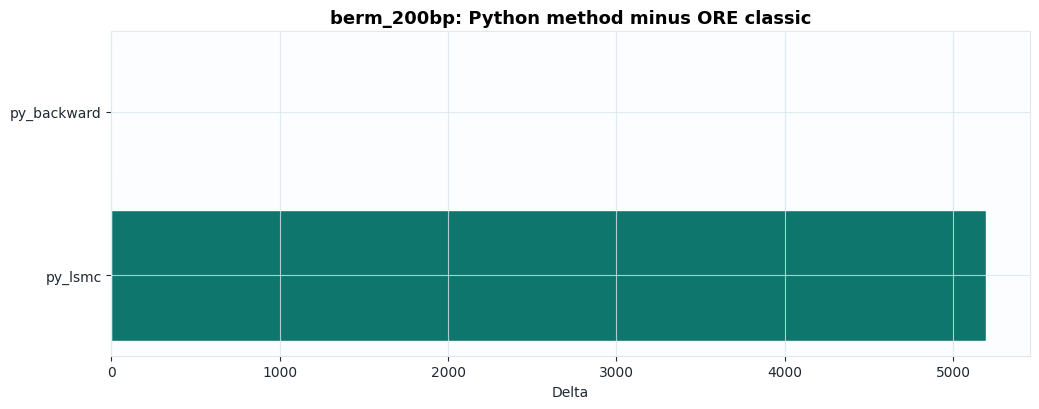

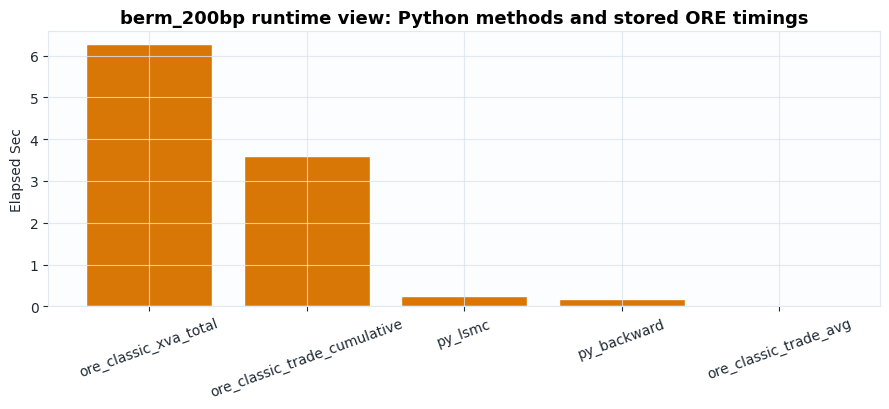

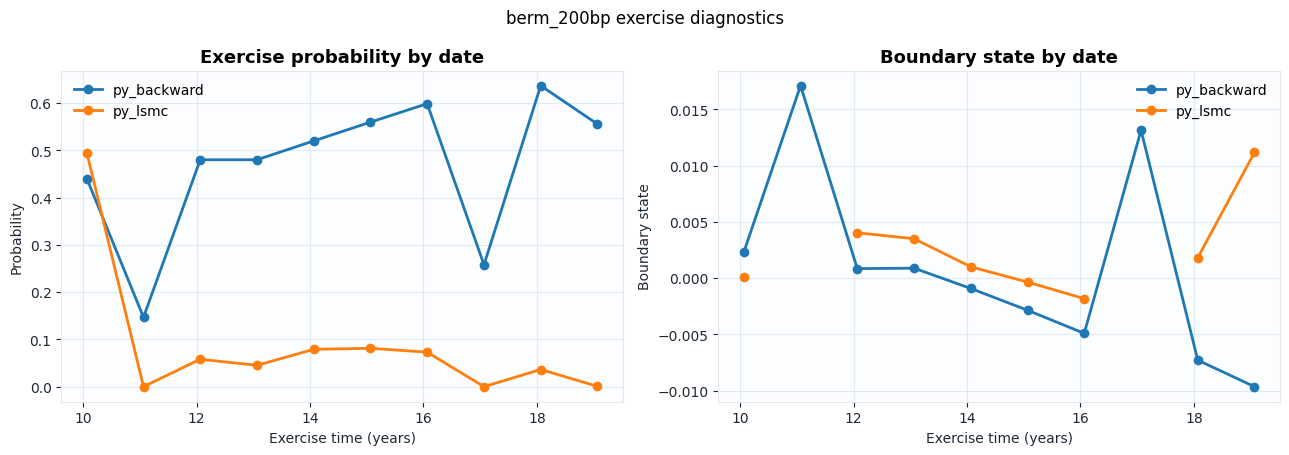

In [3]:
berm_summary, berm_diag, berm_speed, berm_meta = nh.run_bermudan_case_summary("berm_200bp", num_paths=4096, seed=42)
display(pd.DataFrame([berm_meta]))
display(berm_summary)
display(berm_speed)
display(berm_diag)

nh.plot_metric_delta(
    berm_summary.rename(columns={"method": "metric", "delta_vs_ore": "delta"}),
    title="berm_200bp: Python method minus ORE classic",
)
fig, ax = plt.subplots(figsize=(9.0, 4.2))
nh.plot_bar_frame(
    berm_speed,
    "engine",
    "elapsed_sec",
    title="berm_200bp runtime view: Python methods and stored ORE timings",
    color=nh.PALETTE["gold"],
    ax=ax,
)
plt.tight_layout()
plt.show()
plt.close(fig)
nh.plot_bermudan_exercise_diagnostics(berm_diag, title="berm_200bp exercise diagnostics")


The summary table should show `model_param_source = calibration` for both Python methods. That is important:
on these benchmark cases the best parity source is the actual `calibration.xml` emitted by ORE classic, not a
Python-side reconstruction of the trade-specific builder path.


The timing table mixes two sources on purpose:

- Python timings are measured live in the notebook with wall-clock time
- ORE timings come from the stored `pricingstats.csv` and `runtimes.csv` written by the benchmark run

So this section is best read as an operational runtime view, not as a strict apples-to-apples microbenchmark.


## Interpreting the diagnostics

The exercise-probability chart answers “when does the option matter most?”. The boundary-state chart answers
“where is the continuation-versus-exercise switch happening in the LGM state variable?”. Those are the quickest
sanity checks when the aggregate price looks wrong.


## Sensitivity definition example: direct quote bump vs ORE sensitivity analytic

The biggest open issue is not the Bermudan price itself. It is the meaning of the sensitivity number.

For the `berm_200bp` case we now run three calculations live in the notebook:
- ORE `sensitivity.csv`
- direct ORE quote bump-and-reprice
- Python quote bump-and-reprice

This is important because ORE's sensitivity analytic is not the same as "edit one line in the market file and
reprice". It goes through the sensitivity scenario engine and par-conversion layer first.


,case_name,trade_id,method,shift_size,python_price,ore_price,price_diff,ore_run_root,elapsed_sec
0,berm_200bp,BermSwp,backward,0.0001,52294.674108,52289.126872,5.547236,/Users/gordonlee/Documents/Engine/Tools/Python...,20.029292


,normalized_factor,ore_factor,ore_bump_change,ore_direct_quote_bump_change,python_node_bump_change,python_node_minus_ore,python_quote_full_minus_ore_direct,python_quote_full_bump_change,python_quote_fast_bump_change
0,zero:EUR:10Y,DiscountCurve/EUR/0/10Y,-78.79,-0.456001,-2.306379,76.483621,-0.975695,-1.431696,-1.403257
1,fwd:EUR:6M:10Y,IndexCurve/EUR-EURIBOR-6M/0/10Y,368.99,-322.610451,-284.716724,-653.706724,10.416885,-312.193566,-311.814848


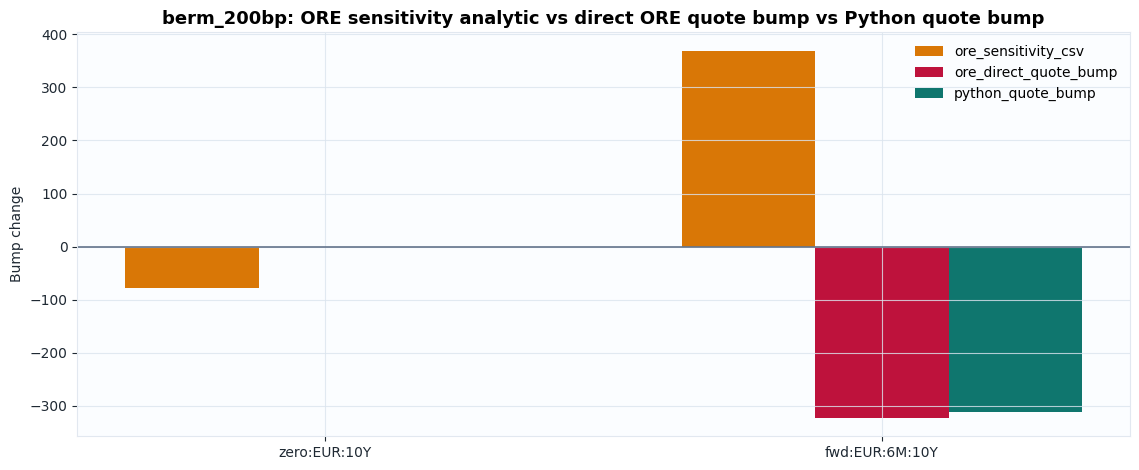

In [4]:
sens_payload, sens_meta, sens_rows, sens_config, sens_scenario = nh.run_bermudan_sensitivity_comparison(
    "berm_200bp",
    method="backward",
    num_paths=256,
    seed=17,
    shift_size=1.0e-4,
)
display(sens_meta)
display(sens_rows)
nh.plot_bermudan_sensitivity_triplet(
    sens_rows,
    title="berm_200bp: ORE sensitivity analytic vs direct ORE quote bump vs Python quote bump",
)


The expected pattern is:

- `python_quote_bump` is close to `ore_direct_quote_bump`
- both can disagree sharply with `ore_sensitivity_csv`

That means the remaining gap is not the Bermudan backward engine. It is the sensitivity-definition layer used by
ORE's analytic.


In [5]:
display(sens_config)

focus_cols = ["#TradeId", "Factor", "ScenarioDescription", "Base NPV", "Scenario NPV", "Difference"]
available_cols = [c for c in focus_cols if c in sens_scenario.columns]
if not available_cols:
    available_cols = list(sens_scenario.columns)
display(sens_scenario[available_cols])


,#Key,Factor,BaseValue,ShiftSize
0,DiscountCurve/EUR/0,DiscountCurve/EUR/0/10Y,0.000000,0.0000
1,DiscountCurve/EUR/6,na,0.020075,0.0001
2,IndexCurve/EUR-EURIBOR-6M/0,IndexCurve/EUR-EURIBOR-6M/0/10Y,0.000000,0.0000
3,IndexCurve/EUR-EURIBOR-6M/6,na,0.019785,0.0001


,#TradeId,Factor,Base NPV,Scenario NPV,Difference
0,BermSwp,DiscountCurve/EUR/0/10Y,52290.48,52211.69,-78.79
1,BermSwp,DiscountCurve/EUR/0/10Y,52290.48,52369.39,78.91
2,BermSwp,IndexCurve/EUR-EURIBOR-6M/0/10Y,52290.48,52659.46,368.99
3,BermSwp,IndexCurve/EUR-EURIBOR-6M/0/10Y,52290.48,51924.21,-366.27


Read the two ORE tables together:

- `sensitivity_config.csv` shows which internal sensitivity key actually moved
- `scenario.csv` shows the up/down scenario NPVs produced by the analytic

On this case the reported factor label `IndexCurve/EUR-EURIBOR-6M/0/10Y` is associated with an internal node key,
not a literal raw-market-file quote bump. That is why the direct ORE bump and the sensitivity analytic can have
different signs.


In [6]:
direct_vs_analytic = sens_rows[
    [
        "normalized_factor",
        "ore_bump_change",
        "ore_direct_quote_bump_change",
        "python_quote_full_bump_change",
        "python_quote_full_minus_ore_direct",
    ]
].copy()
direct_vs_analytic["analytic_minus_direct_ore"] = (
    direct_vs_analytic["ore_bump_change"] - direct_vs_analytic["ore_direct_quote_bump_change"]
)
display(direct_vs_analytic)


,normalized_factor,ore_bump_change,ore_direct_quote_bump_change,python_quote_full_bump_change,python_quote_full_minus_ore_direct,analytic_minus_direct_ore
0,zero:EUR:10Y,-78.79,-0.456001,-1.431696,-0.975695,-78.333999
1,fwd:EUR:6M:10Y,368.99,-322.610451,-312.193566,10.416885,691.600451


The forward `EUR 6M 10Y` row is the headline example:

- ORE sensitivity analytic says the bump change is positive
- direct ORE quote bump says the bump change is negative
- Python quote bump is close to direct ORE quote bump

So if the benchmark objective is "match direct market quote bumping", Python is already on the right side of the
comparison. Matching `sensitivity.csv` would require replicating ORE's par-conversion / sensitivity-scenario
machinery, not changing the Bermudan pricer.


,case_name,py_backward_abs_rel_diff,py_backward_abs_rel_diff_bp
0,berm_100bp,0.002054,20.536549
1,berm_200bp,0.000106,1.060878
2,berm_300bp,0.001945,19.448256


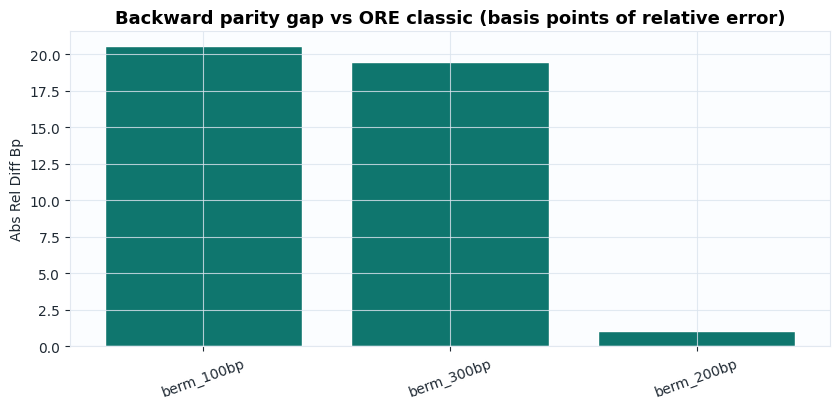

In [7]:
berm_rank = berm_comp[["case_name", "py_backward_abs_rel_diff"]].copy()
berm_rank["py_backward_abs_rel_diff_bp"] = 1.0e4 * berm_rank["py_backward_abs_rel_diff"]
display(berm_rank)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
nh.plot_bar_frame(
    berm_rank.rename(columns={"py_backward_abs_rel_diff_bp": "abs_rel_diff_bp"}),
    "case_name",
    "abs_rel_diff_bp",
    title="Backward parity gap vs ORE classic (basis points of relative error)",
    color=nh.PALETTE["teal"],
    ax=ax,
)
plt.tight_layout()
plt.show()
plt.close(fig)


## Key takeaways

- Use the stored Bermudan comparison pack for the quick multi-case view.
- Use the direct `berm_200bp` repricing section when you want current diagnostics from the live Python code.
- For sensitivities, distinguish direct quote bumping from ORE's sensitivity analytic. They are not the same calculation.
- Treat `backward` as the ORE-classic parity engine and `lsmc` as the control.
- On these Bermudan cases, `calibration.xml` is the right model source whenever ORE has already produced it.
